In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt

## machine learning libraries
import gpytorch 
import torch

## PAMIR libraries
import mlflow
import pamir_mlpermafrost as pamir

install(overflow=True)

In [3]:
config_dir = str(pathlib.Path('../../src/pamir_mlpermafrost/conf').resolve())
config_name = 'laptop-jupyter'
# cfg = pamir.utils.load_hydra_config(config_dir, config_name)

In [4]:
mlflow.set_tracking_uri("file:///home/jovyan/work/pamir-MLpermafrost/mlruns")
exp = mlflow.get_experiment_by_name("full_outputs-lr003")

In [5]:
nc_list = list(pathlib.Path(exp.artifact_location.replace('file://', '')).glob('**/*yhat_avg*.nc'))

In [6]:
def process_single_depth_netcdf(ds):
    path = pathlib.Path(ds.encoding['source'])
    name = path.stem

    season, depth = name.split('yhat_avg_ground_temp')[-1].split('_')
    depth = depth if not depth.startswith('0') else "0." + depth[1:]
    ds = ds.expand_dims(
        season=[season],
        depth=[float(depth)]
    )

    var_list = list(ds)
    renames = {k: k.split('J')[0] for k in var_list}
    ds = ds.rename(renames)
    
    return ds

In [7]:
ds = xr.open_mfdataset(nc_list, preprocess=process_single_depth_netcdf)

In [8]:
with ProgressBarDask():
    ds = ds.chunk(dict(season=2, depth=1, x=1111, y=1111)).persist()

  0%|          | 0/125904 [00:00<?, ?it/s]

In [9]:
sname = '../../data-out/ground_tempSEAS_DEPTH-x7129e34a-covar_poly1_rbf_index-likelihood_gaussian_gt02lt5-opt_adam_lr0.03-seed42.nc'
with ProgressBarDask():
    ds.to_netcdf(
        sname, 
        encoding={k: dict(zlib=True) for k in ds},
        engine='h5netcdf',
    )

  0%|          | 0/770 [00:00<?, ?it/s]

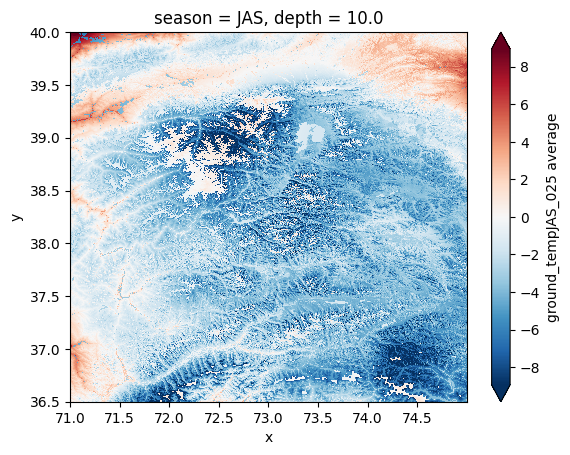

In [150]:
img = ds.yhat_avg_ground_temp[0, -3].plot.imshow(robust=True)

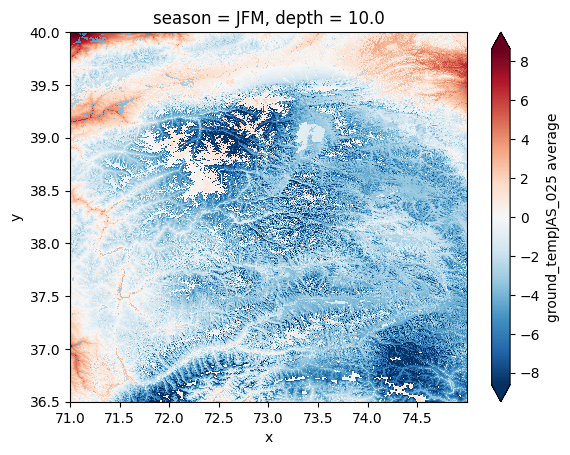

In [151]:
img = ds.yhat_avg_ground_temp[1, -3].plot.imshow(robust=True)

In [15]:
state = "/home/jovyan/work/pamir-MLpermafrost/mlruns/796093033361602612/ddd0549d420e4c1aadcaa3d78218dd57/artifacts/model_state.pt"

In [47]:
cfg.preprocessing.training.keywords['target'] = 'ground_tempJAS_2'

data = cfg.data.training.load().loc[['S180_exp4', 'N180_exp4']]
data_X, data_y = cfg.preprocessing.training(data)

train_X, test_X, train_y, test_y = cfg.preprocessing.train_test_split(data_X, data_y)

scaler_X = cfg.scalers.features.fit(train_X)
scaler_y = cfg.scalers.target.fit(train_y.to_frame())

train_X_scaled = scaler_X.transform(train_X).to(cfg.device)
train_y_scaled = scaler_y.transform(train_y.to_frame()).squeeze().to(cfg.device)

test_X_scaled = scaler_X.transform(test_X).to(cfg.device)
test_y_scaled = scaler_y.transform(test_y.to_frame()).squeeze().to(cfg.device)

In [266]:
state_dict = torch.load(state)

In [53]:
model = cfg.model(
    train_X_scaled, 
    train_y_scaled, 
    likelihood=cfg.likelihood(),
    covar_module=cfg.covar_module(),
).to(cfg.device)

In [310]:
fname = "/home/jovyan/work/pamir-MLpermafrost/mlruns/796093033361602612/f4c6e34a98c24ebf85085c910c6c97c9/artifacts/model_state.pt"
state = torch.load(fname)

In [311]:
raw_keys = {}
for key in state:
    if key.split('.')[-1].startswith('raw_'):
        raw_keys[key] = state[key].cpu().numpy().squeeze()
raw_keys


{
    'likelihood.noise_covar.raw_noise': array(-6.17623, dtype=float32),
    'mean_module.raw_constant': array(0., dtype=float32),
    'covar_module.kernels.0.kernels.0.raw_variance': array(-5.144344, dtype=float32),
    'covar_module.kernels.0.kernels.1.raw_outputscale': array(-0.7888764, dtype=float32),
    'covar_module.kernels.0.kernels.1.base_kernel.raw_lengthscale': array([-0.48343387, -0.07335938, -0.24247058,  
0.9708745 ,  1.9933238 ,
        0.93953055,  0.05155565,  0.91531295,  0.9925785 ,  0.30070263,
        0.7314586 ,  0.84685963,  1.3081478 ,  0.39169124,  1.180794  ,
        0.8397115 ,  0.5405257 ,  0.9972964 , -0.11288633,  1.7307097 ,
        1.1888723 ,  1.5375649 ,  1.7181915 , -0.02470939, -0.64089596,
        0.69439393,  1.0600653 ], dtype=float32),
    'covar_module.kernels.0.kernels.1.base_kernel.raw_alpha': array(-3.6175992, dtype=float32),
    'covar_module.kernels.1.raw_var': array([ 0.31732705, -4.309331  , -1.6655614 , -3.674343  , -4.4407043 ],
     

In [303]:
state#['covar_module.kernels.0.kernels.1.base_kernel.raw_alpha']


OrderedDict({'likelihood.noise_covar.raw_noise': tensor([-6.6825], device='cuda:0'), 
'likelihood.noise_covar.raw_noise_constraint.lower_bound': tensor(0.2000, device='cuda:0'), 
'likelihood.noise_covar.raw_noise_constraint.upper_bound': tensor(5., device='cuda:0'), 'mean_module.raw_constant':
tensor(0., device='cuda:0'), 'covar_module.kernels.0.kernels.0.raw_offset': tensor([0.4481], device='cuda:0'), 
'covar_module.kernels.0.kernels.0.active_dims': tensor([0, 8], device='cuda:0'), 
'covar_module.kernels.0.kernels.0.offset_prior.loc': tensor(0., device='cuda:0'), 
'covar_module.kernels.0.kernels.0.offset_prior.scale': tensor(1., device='cuda:0'), 
'covar_module.kernels.0.kernels.0.raw_offset_constraint.lower_bound': tensor(0., device='cuda:0'), 
'covar_module.kernels.0.kernels.0.raw_offset_constraint.upper_bound': tensor(inf, device='cuda:0'), 
'covar_module.kernels.0.kernels.1.raw_outputscale': tensor(-2.1996, device='cuda:0'), 
'covar_module.kernels.0.kernels.1.active_dims': tensor

In [41]:
model, scores = model.fit(
    train_X_scaled, 
    train_y_scaled, 
    cfg.optimizer(model.parameters()),
    n_iters=500,
    patience=20, 
    tolerance=1e-3,
)

2025-08-13 09:46:43.553 | INFO     | train:train_mll:52 - Iter 10/500 - Loss: 1.363642
2025-08-13 09:46:45.067 | INFO     | train:train_mll:52 - Iter 20/500 - Loss: 1.229438
2025-08-13 09:46:47.110 | INFO     | train:train_mll:52 - Iter 30/500 - Loss: 1.084139
2025-08-13 09:46:48.255 | INFO     | train:train_mll:52 - Iter 40/500 - Loss: 0.946152
2025-08-13 09:46:51.368 | INFO     | train:train_mll:52 - Iter 50/500 - Loss: 0.827570
2025-08-13 09:46:52.786 | INFO     | train:train_mll:52 - Iter 60/500 - Loss: 0.744235
2025-08-13 09:46:54.500 | INFO     | train:train_mll:52 - Iter 70/500 - Loss: 0.685424
2025-08-13 09:46:56.417 | INFO     | train:train_mll:52 - Iter 80/500 - Loss: 0.645530
2025-08-13 09:46:59.681 | INFO     | train:train_mll:52 - Iter 90/500 - Loss: 0.620665
2025-08-13 09:47:00.992 | INFO     | train:train_mll:52 - Iter 100/500 - Loss: 0.605327
2025-08-13 09:47:02.436 | INFO     | train:train_mll:52 - Iter 110/500 - Loss: 0.593452
2025-08-13 09:47:03.885 | INFO     | trai

In [42]:
model.state_dict()


OrderedDict({'likelihood.noise_covar.raw_noise': tensor([-6.1149]), 
'likelihood.noise_covar.raw_noise_constraint.lower_bound': tensor(0.2000), 
'likelihood.noise_covar.raw_noise_constraint.upper_bound': tensor(5.), 'mean_module.raw_constant': tensor(0.), 
'covar_module.kernels.0.kernels.0.raw_offset': tensor([0.2289]), 'covar_module.kernels.0.kernels.0.active_dims': 
tensor([0, 8]), 'covar_module.kernels.0.kernels.0.raw_offset_constraint.lower_bound': tensor(0.), 
'covar_module.kernels.0.kernels.0.raw_offset_constraint.upper_bound': tensor(inf), 
'covar_module.kernels.0.kernels.1.raw_outputscale': tensor(0.3125), 'covar_module.kernels.0.kernels.1.active_dims':
tensor([ 1,  2,  3,  5,  6,  7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29]), 'covar_module.kernels.0.kernels.1.base_kernel.raw_lengthscale': 
tensor([[ 2.8744,  4.0425,  3.3963,  5.6746, 27.6096, 21.3016,  3.6525, 24.8007,
          3.1073, 13.7302, 25.3916, 21.2050,  8.8233,  1.

In [76]:
scores_train = model.score(train_X_scaled, train_y_scaled, scaler_y)
scores_test = model.score(test_X_scaled, test_y_scaled, scaler_y)

pd.DataFrame({
    'train': scores_train,
    'test': scores_test
}).rename(index=lambda x: x.upper()).round(2)

,train,test
MSE,1.39,1.88
RMSE,1.18,1.37
MAE,0.79,0.92
R2,0.90,0.87


In [77]:
from functools import partial

ds_spatial = (
    cfg.data.inference.load()
    .isel(y=slice(2800, 3300), x=slice(1400, 2500))
    .chunk(dict(x=250, y=250)))

dataset = pamir.preprocessing.datasets.DatasetXarraySpatial(
    ds_spatial.persist(),
    chunk_processor=partial(pamir.data.processors.process_X, features=cfg.features),
    scaler=scaler_X,
)

/Users/luke/Work/PAMIR/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/numcodecs/zarr3.py:145: UserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [78]:
yhat_avg, yhat_std = pamir.models.gp.inference.predict(
    model, dataset, scaler_y
)

yhat_avg = dataset.reconstruct_output(yhat_avg)
yhat_std = dataset.reconstruct_output(yhat_std)

2025-08-12 10:15:58.973 | INFO     | inference:predict:24 - Preparing datasets
2025-08-12 10:15:58.973 | INFO     | inference:predict:35 - starting inference


2025-08-12 10:16:00.007 | INFO     | inference:predict:52 - Processed batch 1/10
2025-08-12 10:16:00.970 | INFO     | inference:predict:52 - Processed batch 2/10
2025-08-12 10:16:01.608 | INFO     | inference:predict:52 - Processed batch 3/10
2025-08-12 10:16:02.401 | INFO     | inference:predict:52 - Processed batch 4/10
2025-08-12 10:16:03.032 | INFO     | inference:predict:52 - Processed batch 5/10
2025-08-12 10:16:03.825 | INFO     | inference:predict:52 - Processed batch 6/10
2025-08-12 10:16:04.447 | INFO     | inference:predict:52 - Processed batch 7/10
2025-08-12 10:16:05.099 | INFO     | inference:predict:52 - Processed batch 8/10
2025-08-12 10:16:05.391 | INFO     | inference:predict:52 - Processed batch 9/10
2025-08-12 10:16:05.709 | INFO     | inference:predict:52 - Processed batch 10/10


In [79]:
ds = xr.merge([
    yhat_avg.rename('yhat_avg'),
    yhat_std.rename('yhat_std'),
    ds_spatial])

In [83]:
plot_vars = {
    'yhat_avg': dict(robust=True, cmap='RdBu_r', center=0),
    'yhat_std': dict(robust=True),
    'temperature': dict(robust=True, cmap='RdBu_r', center=273.15),
    'altitude': dict(robust=True, cmap='terrain'),
    'aspect': dict(cmap='twilight_r'),
    'surface_index': dict(robust=True, cmap='turbo', vmin=0, vmax=5)
}

mask = ds.surface_index > 0

ds_plot = ds[list(plot_vars)].where(mask).persist()
for key in ds_plot.keys():
    ds_plot[key].attrs = plot_vars[key]

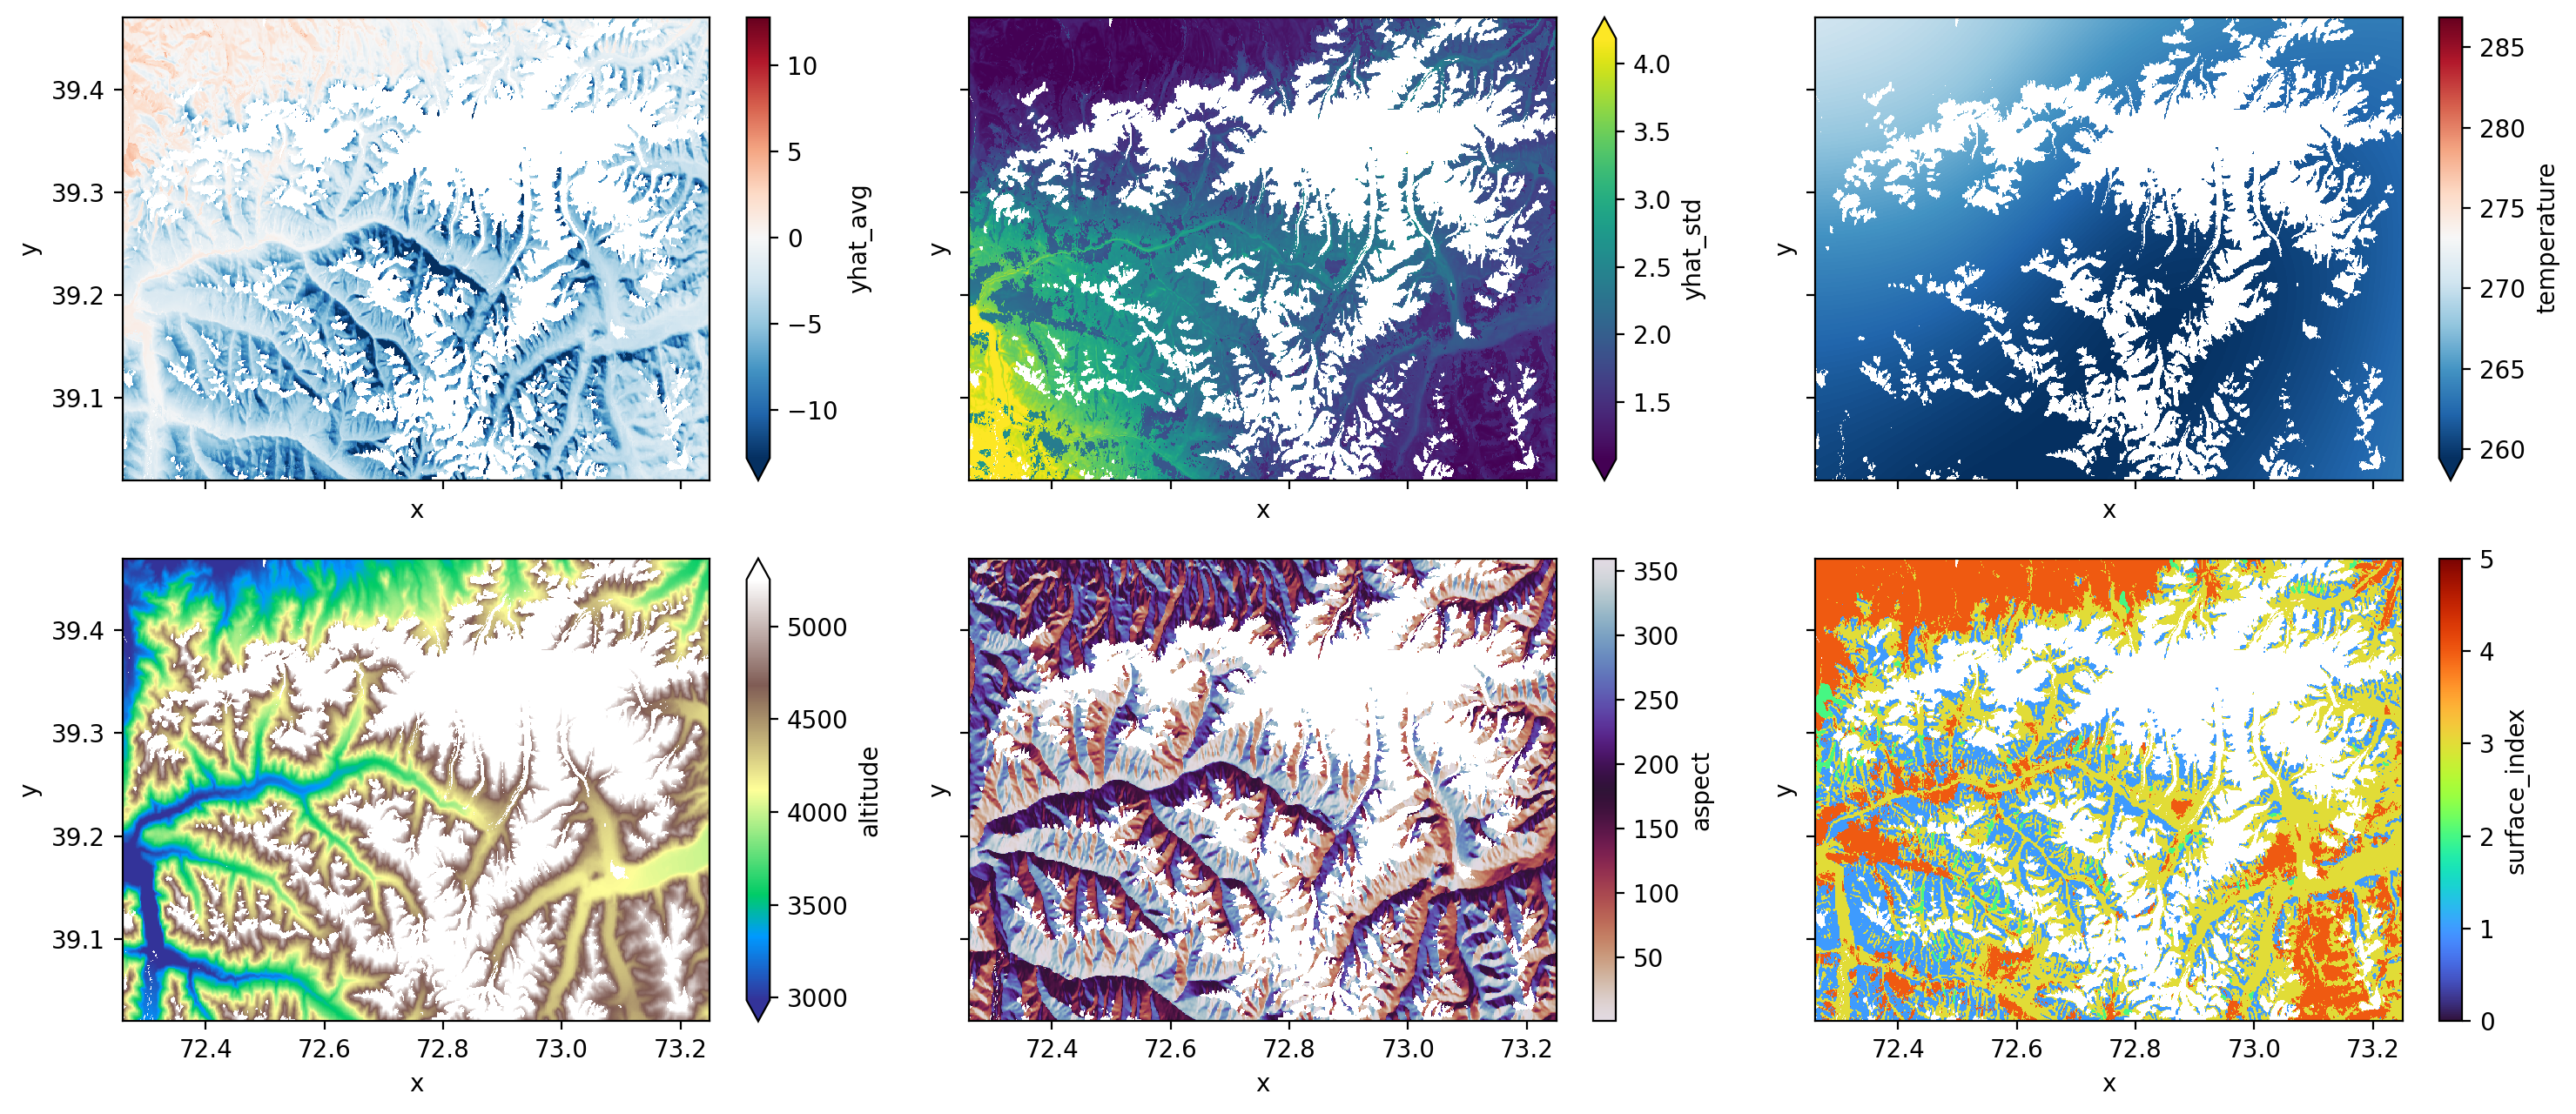

In [84]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6.5), sharex=True, sharey=True, dpi=200)

for key, ax in zip(ds_plot.keys(), axs.flat):
    da = ds_plot[key]
    attrs = da.attrs
    da.plot.imshow(ax=ax, **attrs)

fig.tight_layout()